<a href="https://colab.research.google.com/github/02ShrutiVerma/02ShrutiVerma/blob/main/Titanic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data overview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

<ipython-input-5-57fa55cc7c2f>:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_data, palette='viridis')


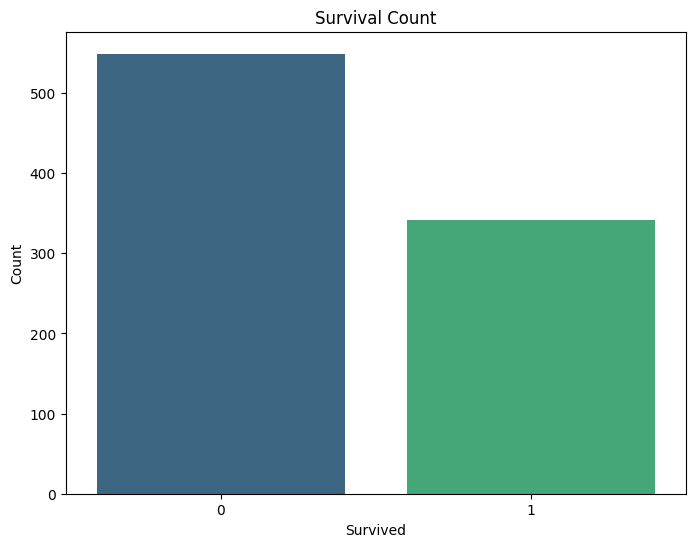

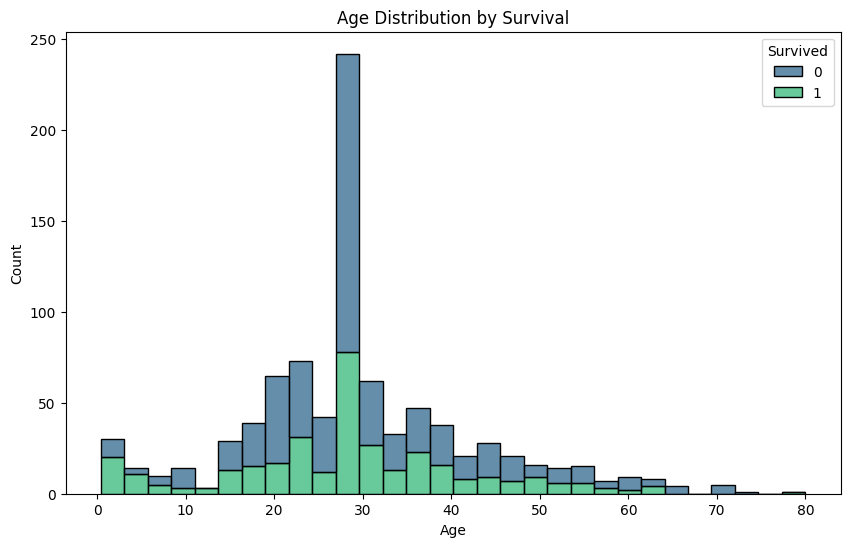

<ipython-input-5-57fa55cc7c2f>:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


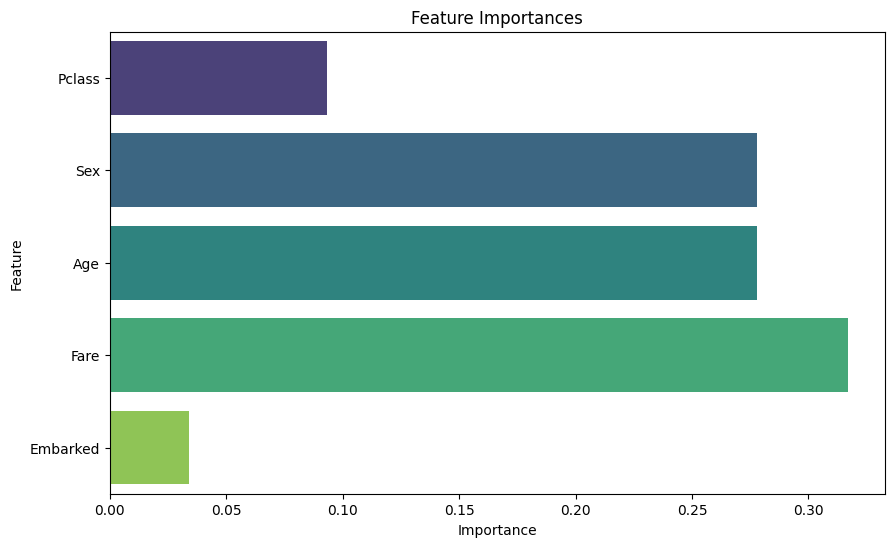

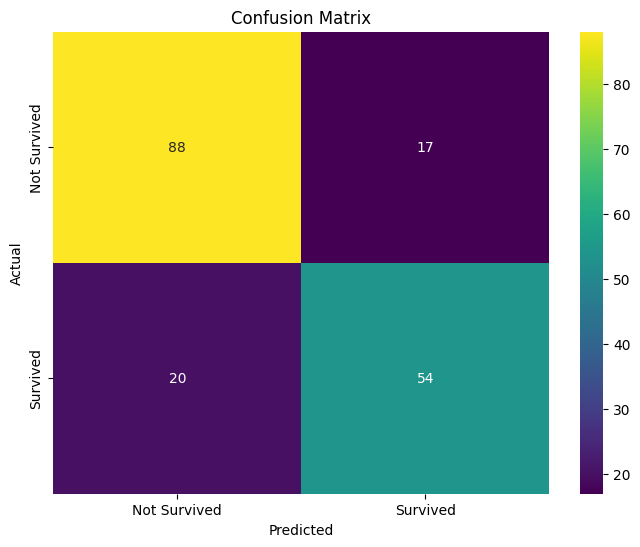

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

print("Training data overview:")
print(train_data.head())


train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
X = train_data[features]
y = train_data['Survived']
X_test = test_data[features]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_val, y_pred))

test_predictions = model.predict(X_test)


submission = pd.DataFrame({'PassengerId': test_data['PassengerId'], 'Survived': test_predictions})
submission.to_csv("gender_submission.csv", index=False)
print("Prediction saved to 'gender_submission.csv'")


# Plot visualization1: Survival Count Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=train_data, palette='viridis')
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Plot visualization 2: Age Distribution by Survival
plt.figure(figsize=(10, 6))
sns.histplot(data=train_data, x='Age', hue='Survived', multiple='stack', palette='viridis', bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Plot visualization 3: Feature Importance Plot
importances = model.feature_importances_
feature_names = features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Plot visualization 4: Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



In [ ]:
I have tried to add some extra features like

1.surname grouping = This feature represents the average survival rate of passengers with the same surname,
providing insight into family/group survival tendencies ,

2.ticket group survival probability = This feature captures the survival probability based on the ticket number,
indicating the likelihood of group survival for people who shared a ticket,

3.is child or elderly = These features help identify vulnerable age groups (children and the elderly), which could affect survival chances.

in the code mentioned below.

Training data overview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

<ipython-input-1-e2c9b323015e>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
<ipython-input-1-e2c9b323015e>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Validation Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       105
           1       1.00      0.99      0.99        74

    accuracy                           0.99       179
   macro avg       1.00      0.99      0.99       179
weighted avg       0.99      0.99      0.99       179

Prediction saved to 'gender_submission.csv'


<ipython-input-1-e2c9b323015e>:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_data, palette='viridis')


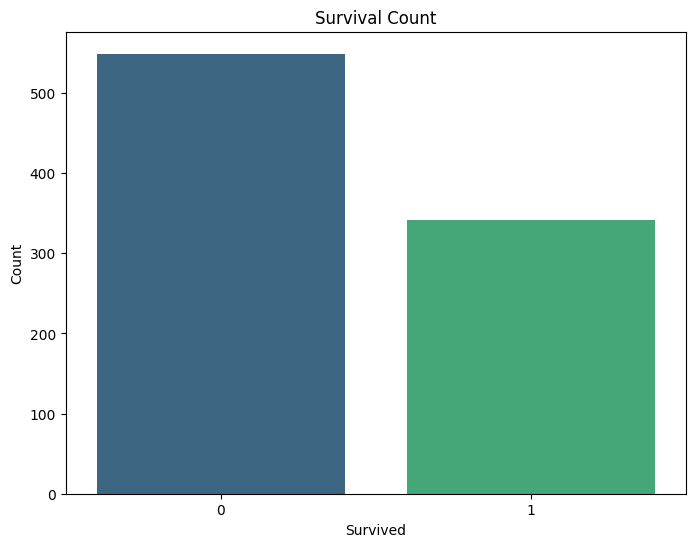

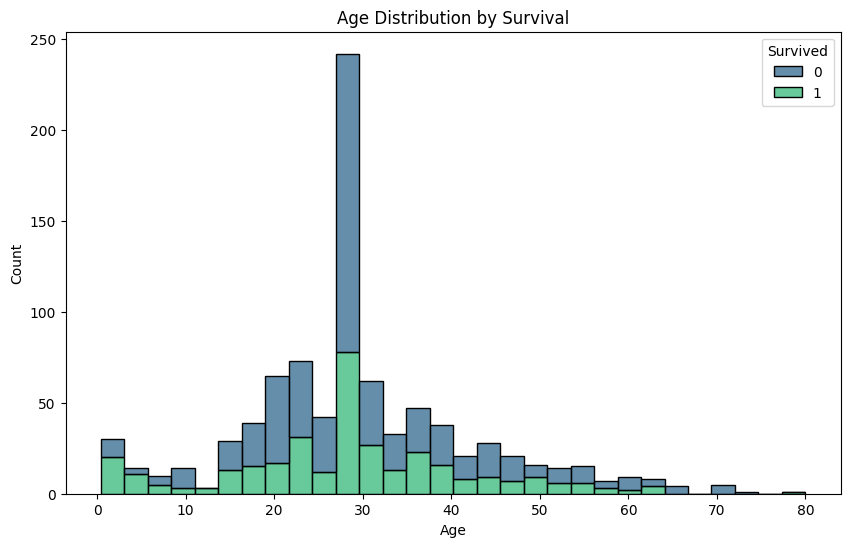

<ipython-input-1-e2c9b323015e>:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


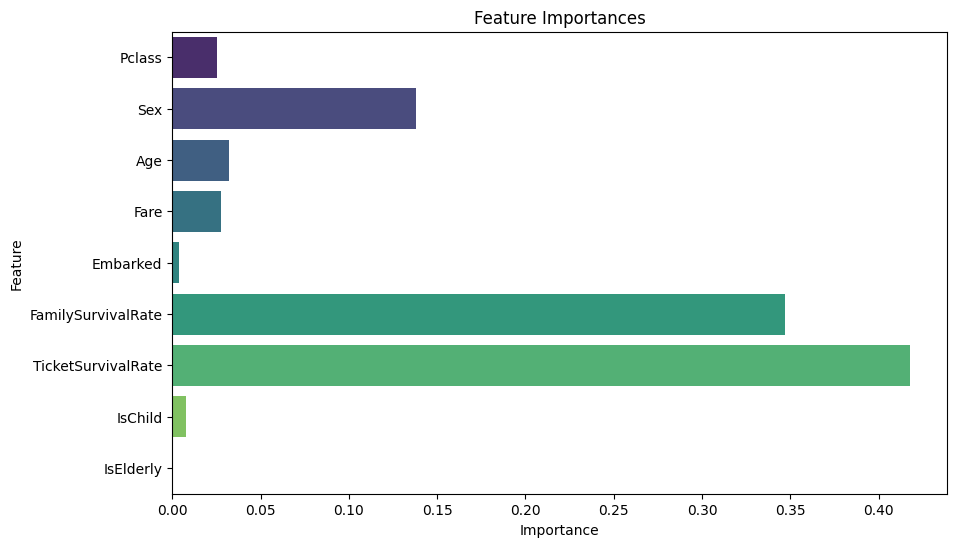

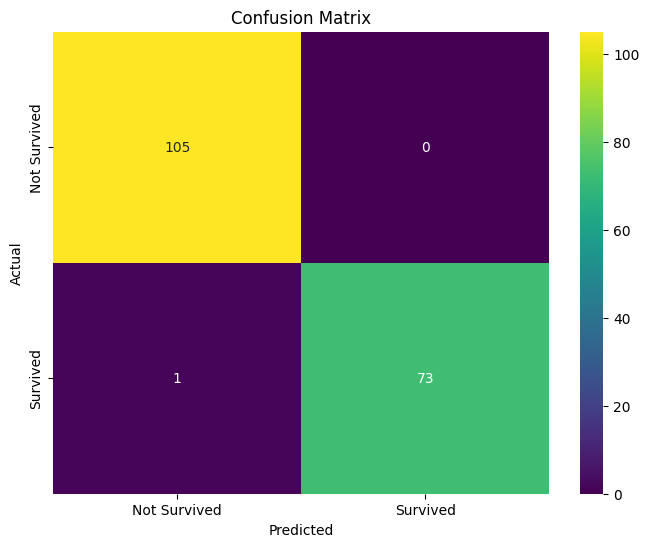

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')


print("Training data overview:")
print(train_data.head())


train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


## 1. Surname Grouping (Family Group Survival Probability)
train_data['Surname'] = train_data['Name'].str.split(',').str[0]
test_data['Surname'] = test_data['Name'].str.split(',').str[0]

# Calculating the survival rate for each surname
surname_survival_rate = train_data.groupby('Surname')['Survived'].mean()


train_data['FamilySurvivalRate'] = train_data['Surname'].map(surname_survival_rate)
test_data['FamilySurvivalRate'] = test_data['Surname'].map(surname_survival_rate)
train_data['FamilySurvivalRate'].fillna(train_data['Survived'].mean(), inplace=True)
test_data['FamilySurvivalRate'].fillna(train_data['Survived'].mean(), inplace=True)

## 2. Ticket Group Survival Probability
ticket_survival_rate = train_data.groupby('Ticket')['Survived'].mean()

train_data['TicketSurvivalRate'] = train_data['Ticket'].map(ticket_survival_rate)
test_data['TicketSurvivalRate'] = test_data['Ticket'].map(ticket_survival_rate)
train_data['TicketSurvivalRate'].fillna(train_data['Survived'].mean(), inplace=True)
test_data['TicketSurvivalRate'].fillna(train_data['Survived'].mean(), inplace=True)

## 3. Is Child or Elderly
train_data['IsChild'] = (train_data['Age'] < 12).astype(int)
test_data['IsChild'] = (test_data['Age'] < 12).astype(int)
train_data['IsElderly'] = (train_data['Age'] > 60).astype(int)
test_data['IsElderly'] = (test_data['Age'] > 60).astype(int)


features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked',
            'FamilySurvivalRate', 'TicketSurvivalRate', 'IsChild', 'IsElderly']
X = train_data[features]
y = train_data['Survived']
X_test = test_data[features]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_val, y_pred))


test_predictions = model.predict(X_test)


submission = pd.DataFrame({'PassengerId': test_data['PassengerId'], 'Survived': test_predictions})
submission.to_csv('gender_submission.csv', index=False)
print("Prediction saved to 'gender_submission.csv'")


## Plot visualization 1: Survival Count
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=train_data, palette='viridis')
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

## Plot visualization2: Age Distribution by Survival
plt.figure(figsize=(10, 6))
sns.histplot(data=train_data, x='Age', hue='Survived', multiple='stack', palette='viridis', bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Plot visualization 3: Feature Importance
importances = model.feature_importances_
feature_names = features

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Plot visualization 4: Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
